In [14]:
from pathlib import Path

DATA_RAW = Path("../data/raw")
DATA_RAW.mkdir(parents=True, exist_ok=True)

arquivos = list(DATA_RAW.glob("*"))
print(f"Arquivos encontrados: {len(arquivos)}\n")
for f in arquivos:
    print(f"{f.name} - {f.stat().st_size / 1024:.1f} KB")

Arquivos encontrados: 3

seqs_test.txt - 29.9 KB
Neg_train_fasta.txt - 78.0 KB
Pos_train_fasta.txt - 56.3 KB


In [15]:
from Bio import SeqIO

# Identifica todos os arquivos FASTA
fasta_files = list(DATA_RAW.glob("*.txt"))

# Carrega cada um em um dicionário
dados = {}
for arquivo in fasta_files:
    records = list(SeqIO.parse(arquivo, "fasta"))
    dados[arquivo.stem] = records  # usa nome do arquivo como chave
    print(f"{arquivo.name}: {len(records)} sequências")

print(f"\nArquivos carregados: {list(dados.keys())}")

seqs_test.txt: 970 sequências
Neg_train_fasta.txt: 1940 sequências
Pos_train_fasta.txt: 1940 sequências

Arquivos carregados: ['seqs_test', 'Neg_train_fasta', 'Pos_train_fasta']


In [16]:
# Mostra as 2 primeiras sequências de cada arquivo
for nome_arquivo, records in dados.items():
    print(f"\n{'='*60}")
    print(f"Arquivo: {nome_arquivo}")
    print(f"{'='*60}")
    
    for i, rec in enumerate(records[:2]):
        print(f"\n[{i}] ID: {rec.id}")
        print(f"    Descrição: {rec.description}")
        print(f"    Tamanho: {len(rec.seq)} bp")
        print(f"    Primeiros 10 caracteres: {str(rec.seq)[:10]}...")


Arquivo: seqs_test

[0] ID: NP00317
    Descrição: NP00317
    Tamanho: 10 bp
    Primeiros 10 caracteres: AGWSSLKGAW...

[1] ID: NP00717
    Descrição: NP00717
    Tamanho: 17 bp
    Primeiros 10 caracteres: DALSPPAAGL...

Arquivo: Neg_train_fasta

[0] ID: non-NeuroP002366
    Descrição: non-NeuroP002366
    Tamanho: 17 bp
    Primeiros 10 caracteres: FLPLLAASFA...

[1] ID: non-NeuroP014978
    Descrição: non-NeuroP014978
    Tamanho: 6 bp
    Primeiros 10 caracteres: QVHHQK...

Arquivo: Pos_train_fasta

[0] ID: NP04987
    Descrição: NP04987
    Tamanho: 8 bp
    Primeiros 10 caracteres: SVQFKPRL...

[1] ID: NP05606
    Descrição: NP05606
    Tamanho: 10 bp
    Primeiros 10 caracteres: APLMGFQGVR...


In [17]:
import pandas as pd

# Cria DataFrame com estatísticas para cada arquivo
for nome_arquivo, records in dados.items():
    stats = []
    for rec in records:
        stats.append({
            "id": rec.id,
            "length": len(rec.seq),
            "gc_content": sum(rec.seq.count(x) for x in "GCgc") / len(rec.seq) * 100 if len(rec.seq) > 0 else 0,
            "n_count": rec.seq.count("N") + rec.seq.count("n"),
        })
    
    df = pd.DataFrame(stats)
    print(f"\n{'='*60}")
    print(f"Arquivo: {nome_arquivo}")
    print(f"{'='*60}")
    print(df.describe())


Arquivo: seqs_test
           length  gc_content     n_count
count  970.000000  970.000000  970.000000
mean    21.106186   11.212066    0.887629
std     18.579483   10.235362    1.218515
min      5.000000    0.000000    0.000000
25%     10.000000    1.517991    0.000000
50%     15.000000   10.000000    0.000000
75%     24.000000   16.666667    1.000000
max    100.000000   56.250000    8.000000

Arquivo: Neg_train_fasta
            length   gc_content      n_count
count  1940.000000  1940.000000  1940.000000
mean     22.144845    12.056406     0.920619
std      17.926679    10.896214     1.232986
min       5.000000     0.000000     0.000000
25%      12.000000     4.624736     0.000000
50%      16.000000    10.000000     1.000000
75%      25.000000    16.666667     1.000000
max     100.000000    57.142857     9.000000

Arquivo: Pos_train_fasta
            length   gc_content      n_count
count  1940.000000  1940.000000  1940.000000
mean     19.700515    11.047022     0.841237
std      1

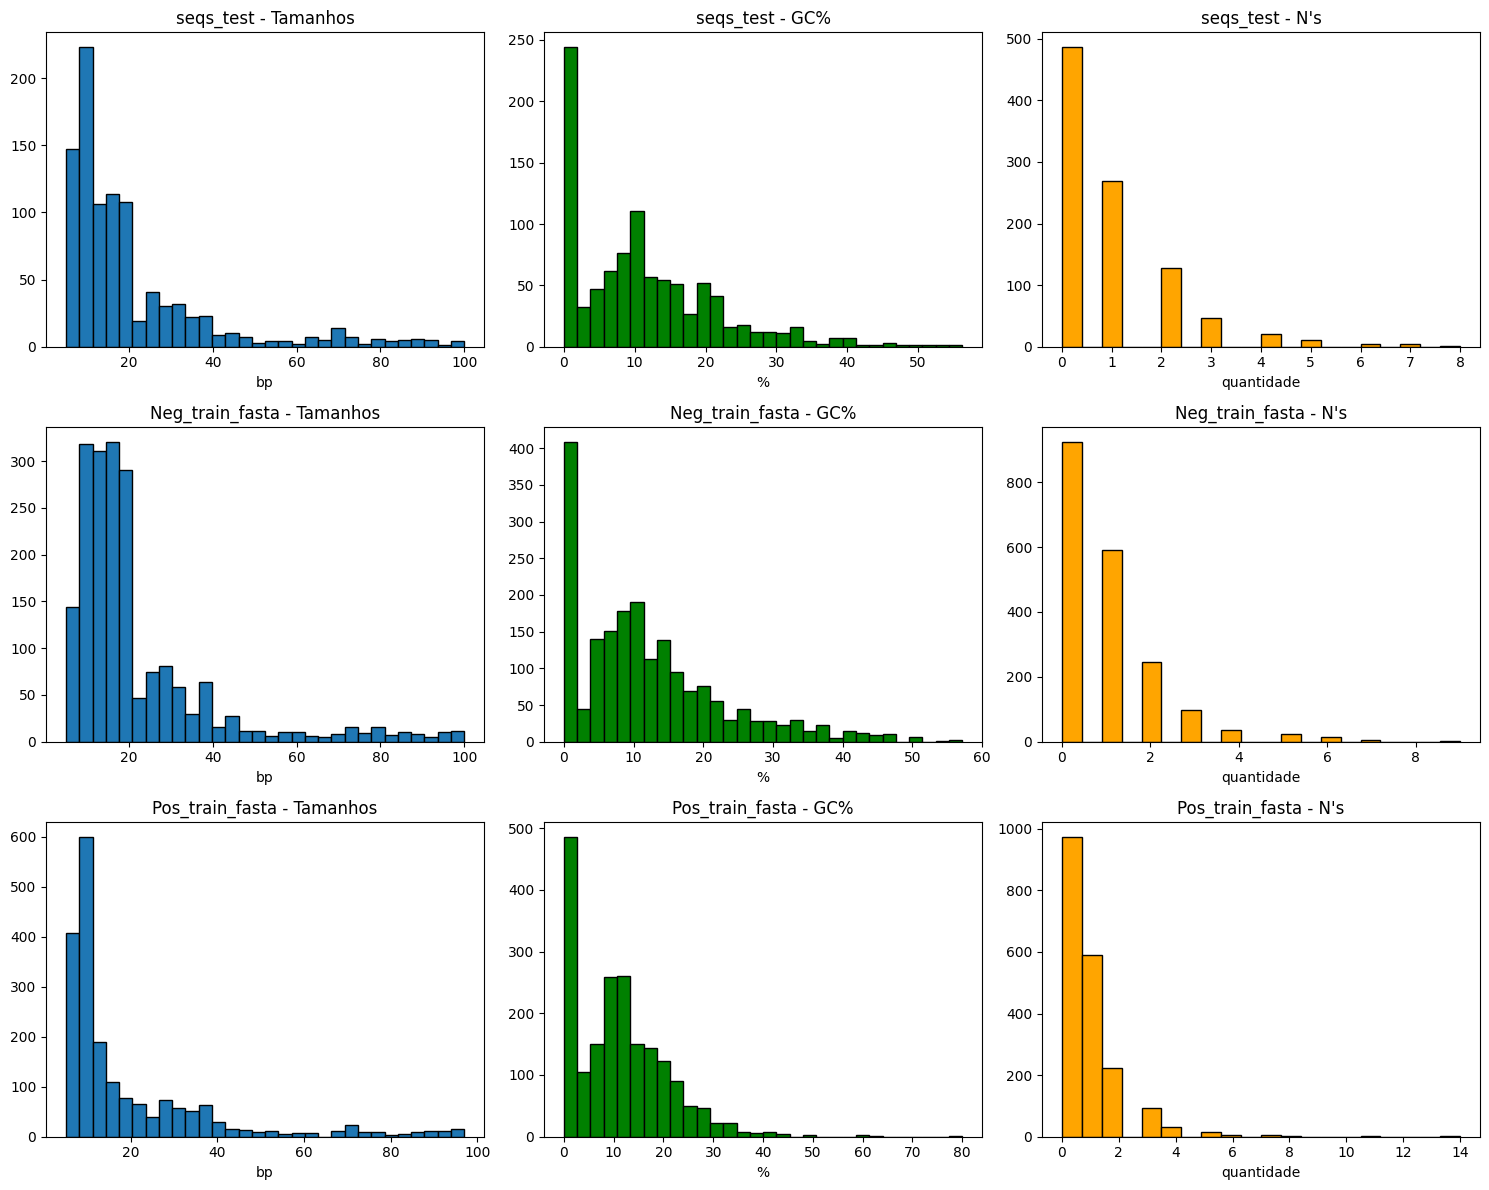

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for idx, (nome, records) in enumerate(dados.items()):
    stats = pd.DataFrame([
        {"length": len(r.seq), 
         "gc": sum(r.seq.count(x) for x in "GCgc") / len(r.seq) * 100,
         "n": r.seq.count("N") + r.seq.count("n")}
        for r in records
    ])
    
    # Tamanhos
    axes[idx, 0].hist(stats["length"], bins=30, edgecolor="black")
    axes[idx, 0].set_title(f"{nome} - Tamanhos")
    axes[idx, 0].set_xlabel("bp")
    
    # GC content
    axes[idx, 1].hist(stats["gc"], bins=30, color="green", edgecolor="black")
    axes[idx, 1].set_title(f"{nome} - GC%")
    axes[idx, 1].set_xlabel("%")
    
    # N count
    axes[idx, 2].hist(stats["n"], bins=20, color="orange", edgecolor="black")
    axes[idx, 2].set_title(f"{nome} - N's")
    axes[idx, 2].set_xlabel("quantidade")

plt.tight_layout()
plt.show()

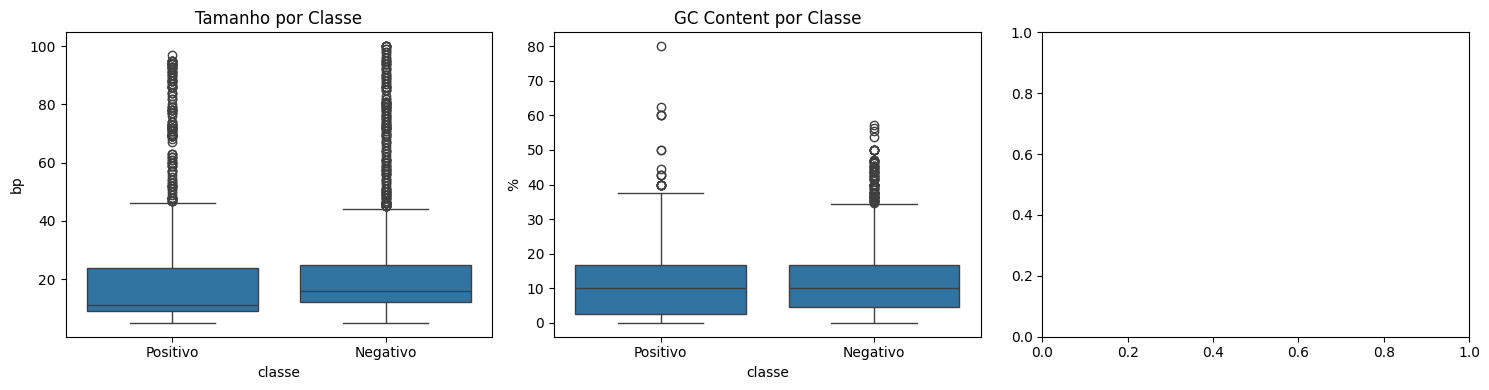

In [20]:
# Compara as classes de treino lado a lado
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Prepara dados
pos_stats = pd.DataFrame([
    {"length": len(r.seq), "gc": sum(r.seq.count(x) for x in "GCgc") / len(r.seq) * 100}
    for r in dados["Pos_train_fasta"]
])
pos_stats["classe"] = "Positivo"

neg_stats = pd.DataFrame([
    {"length": len(r.seq), "gc": sum(r.seq.count(x) for x in "GCgc") / len(r.seq) * 100}
    for r in dados["Neg_train_fasta"]
])
neg_stats["classe"] = "Negativo"

combined = pd.concat([pos_stats, neg_stats])

# Boxplot tamanhos
sns.boxplot(data=combined, x="classe", y="length", ax=axes[0])
axes[0].set_title("Tamanho por Classe")
axes[0].set_ylabel("bp")

# Boxplot GC content
sns.boxplot(data=combined, x="classe", y="gc", ax=axes[1])
axes[1].set_title("GC Content por Classe")
axes[1].set_ylabel("%")

plt.tight_layout()
plt.show()